
## Question 2. 
---------

### 2.2 Building Markov transition matrix

You have learned important differences between simple dinucleotide frequency
model and Markov models. Your goal is to build one from the input sequence. In
the Jupyter notebook, you should print the transition matrix.

---------

In [1]:
import numpy as np
import pandas as pd
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
input_fasta_file = "multiline_input.fasta"

sequence_list = []

with open(input_fasta_file, 'r') as fasta:
    for line in fasta:
        line = line.strip()
        if not line.startswith('>'):
            sequence_list.append(line)

combined_sequence = ''.join(sequence_list)


#counting Dinucleotide Transitions

valid_nucleotides = ['A', 'C', 'G', 'T']
transition_matrix_data = defaultdict(lambda: defaultdict(int))
for index in range(len(combined_sequence) - 1):
    curr = combined_sequence[index]
    nxt = combined_sequence[index + 1]
    # Checking if both nucleotides are valid
    if curr in valid_nucleotides and nxt in valid_nucleotides:
        transition_matrix_data[curr][nxt] += 1



# Building the proper Markov transition matrix.
transition_matrix = pd.DataFrame(index=valid_nucleotides, columns=valid_nucleotides)
for a in valid_nucleotides:
    total = sum(transition_matrix_data[a].values())
    for b in valid_nucleotides:
        if total > 0:
            transition_matrix.loc[a, b] = transition_matrix_data[a][b] / total
        else:
            transition_matrix.loc[a, b] = 0.0
transition_matrix = transition_matrix.astype(float)

Plotting the Heatmap for MultiLine_Input.fasta

-----

Markov Transition Matrix :


,A,C,G,T
A,0.250870,0.242645,0.264790,0.241696
C,0.246548,0.254438,0.244905,0.254109
G,0.251826,0.247380,0.255637,0.245157
T,0.270936,0.237438,0.250246,0.241379


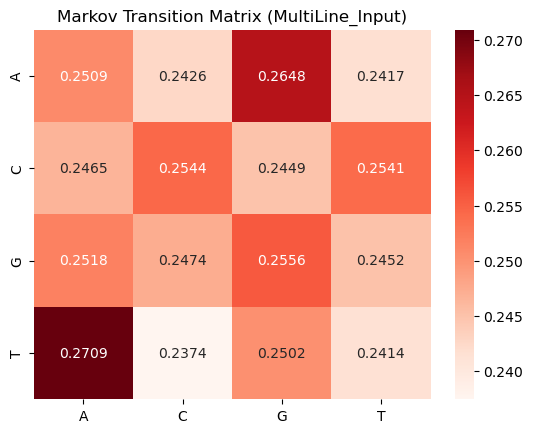

In [3]:
print("Markov Transition Matrix :")
display(transition_matrix)
print("\n")

sns.heatmap(transition_matrix, annot=True, cmap="Reds", fmt=".4f")
plt.title("Markov Transition Matrix (MultiLine_Input)")
plt.show()

#### Extra Check
------

Now just to check the correctness of our solution to Q2_1 which was to convert Multi-line sequence fasta to single-line fasta file.
We will do the same for SingleLine fasta file which we have already created in Q2_1.
We should get the same result as we got for multiline_input file.

------


Markov Transition Matrix :


,A,C,G,T
A,0.250870,0.242645,0.264790,0.241696
C,0.246548,0.254438,0.244905,0.254109
G,0.251826,0.247380,0.255637,0.245157
T,0.270936,0.237438,0.250246,0.241379


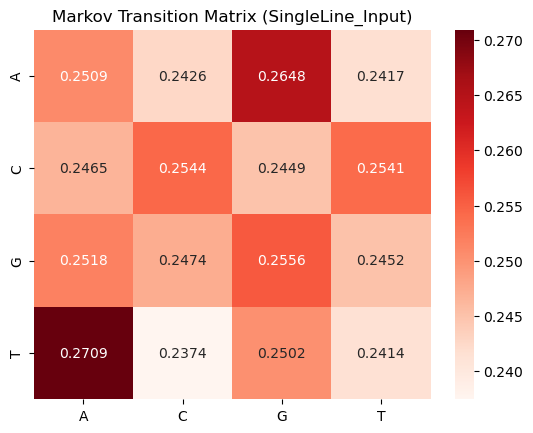

In [4]:
input_fasta_file = "singleline_input.fasta"

sequence_list = []

with open(input_fasta_file, 'r') as fasta:
    for line in fasta:
        line = line.strip()
        if not line.startswith('>'):
            sequence_list.append(line)

combined_sequence = ''.join(sequence_list)


#counting Dinucleotide Transitions

valid_nucleotides = ['A', 'C', 'G', 'T']
transition_matrix_data = defaultdict(lambda: defaultdict(int))
for index in range(len(combined_sequence) - 1):
    curr = combined_sequence[index]
    nxt = combined_sequence[index + 1]
    # Checking if both nucleotides are valid
    if curr in valid_nucleotides and nxt in valid_nucleotides:
        transition_matrix_data[curr][nxt] += 1



# Building the proper Markov transition matrix.
transition_matrix = pd.DataFrame(index=valid_nucleotides, columns=valid_nucleotides)
for a in valid_nucleotides:
    total = sum(transition_matrix_data[a].values())
    for b in valid_nucleotides:
        if total > 0:
            transition_matrix.loc[a, b] = transition_matrix_data[a][b] / total
        else:
            transition_matrix.loc[a, b] = 0.0
transition_matrix = transition_matrix.astype(float)

print("Markov Transition Matrix :")
display(transition_matrix)
print("\n")

sns.heatmap(transition_matrix, annot=True, cmap="Reds", fmt=".4f")
plt.title("Markov Transition Matrix (SingleLine_Input)")
plt.show()